# Notebook 03: Document OCR & PDF Extraction

**Time:** 30 minutes  
**Prerequisites:** Notebook 02 complete  
**Goal:** Extract text from images and PDFs using OCR -- from baseline (Tesseract) to modern tools (Marker, Docling)

This notebook will:
1. Use Tesseract OCR as a baseline (simple, offline)
2. Compare with EasyOCR (PyTorch-based, 80+ languages)
3. Explore Marker for PDF-to-Markdown conversion (2025 state-of-the-art)
4. Try Docling for enterprise document processing

> **Why this matters:** Real LLM pretraining data comes from PDFs, scanned documents, and images -- not just clean web text. Meta's LLaMA 4 used PDF extraction as a key data source. Tools have evolved dramatically: Tesseract (2006) -> EasyOCR (2020) -> Marker/Docling (2025).

In [1]:
import os, sys, time, importlib
from pathlib import Path

notebook_dir = os.getcwd()
parent_dir   = str(Path(notebook_dir).parent)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

from dotenv import load_dotenv
load_dotenv(os.path.join(parent_dir, '.env'), override=True)

%matplotlib inline
import matplotlib.pyplot as plt

import src.llm_client, src.cost_tracker, src.utils, src.config
for mod in [src.llm_client, src.cost_tracker, src.utils, src.config]:
    importlib.reload(mod)

from src.llm_client import LLMClient
from src.cost_tracker import CostTracker
from src.utils import format_response, append_to_reflection
import src.config as config

import src.ocr_utils
importlib.reload(src.ocr_utils)
from src.ocr_utils import (
    ocr_with_tesseract,
    compare_ocr_methods,
)

client  = LLMClient(path=config.PATH)
tracker = CostTracker()

outputs_dir = os.path.join('..', 'outputs')
os.makedirs(outputs_dir, exist_ok=True)

print("Setup complete -- ready for Notebook 03")

✓ Claude API client initialized
  Default model: claude-sonnet-4-6
  Available: claude-sonnet-4-6, claude-opus-4-6, claude-haiku-4-5-20251001
Setup complete -- ready for Notebook 03


---

## Part 1: Tesseract OCR (Baseline)

Tesseract is the classic open-source OCR engine (originally by HP, now maintained by Google). It works offline and handles simple, single-column text well.

**Strengths:** Free, offline, simple to use  
**Weaknesses:** Struggles with complex layouts, math, multi-column, low-res scans

Experiment 1: Tesseract OCR on Sample Image



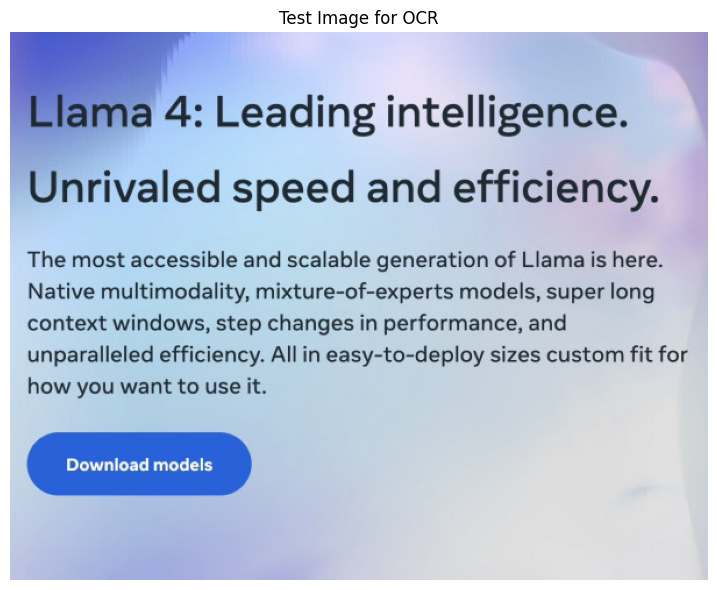

TESSERACT OCR
Image: /Users/scottlai/Documents/inferenceAI/Homework3-Submission/test_data/image/image.png
  Preprocessed: grayscale conversion
  Extracted 324 chars in 0.2s
  Preview: a 4: Leading intelligence.

Unrivaled speed and efficiency.

The most accessible and scalable generation of Llama is here.
Native multimodality, mixture-of-experts models, super long
context windows, ...


In [2]:
print("=" * 65)
print("Experiment 1: Tesseract OCR on Sample Image")
print("=" * 65)
print()

# Use a test image -- you can replace with your own
test_image = os.path.join(parent_dir, 'test_data', 'image', 'image.png')

if os.path.exists(test_image):
    # Display the image
    from PIL import Image
    img = Image.open(test_image)
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title('Test Image for OCR')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    # Run OCR
    tess_result = ocr_with_tesseract(test_image)
else:
    print(f"Test image not found: {test_image}")
    print("Creating a sample image for OCR testing...")
    
    from PIL import Image, ImageDraw, ImageFont
    img = Image.new('RGB', (600, 200), 'white')
    draw = ImageDraw.Draw(img)
    draw.text((20, 30), "LLM Pretraining Data Pipeline", fill='black')
    draw.text((20, 70), "Step 1: Collect data from web, PDFs, audio", fill='black')
    draw.text((20, 110), "Step 2: Clean and deduplicate", fill='black')
    draw.text((20, 150), "Step 3: Filter by quality and language", fill='black')
    
    test_image = os.path.join(outputs_dir, 'sample_ocr_test.png')
    img.save(test_image)
    print(f"Sample image saved to: {test_image}")
    
    tess_result = ocr_with_tesseract(test_image)

In [3]:
# TODO 1: Evaluate Tesseract Quality
#
# Look at the Tesseract output above. What did it get right/wrong?
# Consider: layout preservation, special characters, text ordering.

print("=" * 65)
print("TODO 1: Tesseract Quality Analysis")
print("=" * 65)
print()

print("Full Tesseract output:")
print(tess_result['text'])

todo1_reflection = """
[YOUR REFLECTION HERE]

- What text did Tesseract extract correctly?
- Were there any errors, missing text, or ordering issues?
- For what types of documents would Tesseract be sufficient?
"""

print()
print(todo1_reflection)

TODO 1: Tesseract Quality Analysis

Full Tesseract output:
a 4: Leading intelligence.

Unrivaled speed and efficiency.

The most accessible and scalable generation of Llama is here.
Native multimodality, mixture-of-experts models, super long
context windows, step changes in performance, and
unparalleled efficiency. All in easy-to-deploy sizes custom fit for
how you want to use it.


[YOUR REFLECTION HERE]

- What text did Tesseract extract correctly?
- Were there any errors, missing text, or ordering issues?
- For what types of documents would Tesseract be sufficient?



---

## Part 2: EasyOCR (PyTorch-Based)

**EasyOCR** is a PyTorch-based OCR system supporting 80+ languages. It uses CRAFT for text detection and CRNN for recognition, offering better accuracy than Tesseract on many document types.

```
pip install easyocr
```

In [4]:
print("=" * 65)
print("Experiment 2: EasyOCR vs Tesseract Comparison")
print("=" * 65)
print()

try:
    comparison = compare_ocr_methods(test_image, methods=["tesseract", "easyocr"])
    
    print("\n--- Tesseract output ---")
    if 'error' not in comparison.get('tesseract', {}):
        print(comparison['tesseract']['text'][:300])
    
    print("\n--- EasyOCR output ---")
    if 'error' not in comparison.get('easyocr', {}):
        print(comparison['easyocr']['text'][:300])
        print(f"\nEasyOCR detected {len(comparison['easyocr'].get('lines', []))} text lines")
except Exception as e:
    print(f"Comparison failed: {e}")
    print("TIP: Surya requires PyTorch. Install with: pip install easyocr")

Experiment 2: EasyOCR vs Tesseract Comparison

OCR METHOD COMPARISON
Image: /Users/scottlai/Documents/inferenceAI/Homework3-Submission/test_data/image/image.png

TESSERACT OCR
Image: /Users/scottlai/Documents/inferenceAI/Homework3-Submission/test_data/image/image.png
  Preprocessed: grayscale conversion
  Extracted 324 chars in 0.2s
  Preview: a 4: Leading intelligence.

Unrivaled speed and efficiency.

The most accessible and scalable generation of Llama is here.
Native multimodality, mixture-of-experts models, super long
context windows, ...
EASYOCR
Image: /Users/scottlai/Documents/inferenceAI/Homework3-Submission/test_data/image/image.png
Languages: ['en']
  Extracted 8 text regions, 341 chars in 1.6s
  Average confidence: 0.826

--- Comparison ---
  tesseract: 324 chars in 0.2s
  easyocr: 341 chars in 1.6s

--- Tesseract output ---
a 4: Leading intelligence.

Unrivaled speed and efficiency.

The most accessible and scalable generation of Llama is here.
Native multimodality, mixture

/Users/scottlai/Documents/inferenceAI/Homework3-Submission/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


---

## Part 3: Marker -- PDF to Markdown (2025 State-of-the-Art)

**Marker** is by VikParuchuri (same creator as Surya). It's the modern evolution -- a complete PDF-to-Markdown pipeline that handles:
- Multi-column layouts
- Tables and figures
- Code blocks
- Mathematical notation

In benchmarks (2026), Marker is the recommended "safest default" for PDF extraction.

```
pip install marker-pdf
```

In [ ]:
print("=" * 65)
print("Experiment 3: Marker PDF Extraction")
print("=" * 65)
print()

# Try to find a PDF in test_data or use the course presentation
test_pdf = None
pdf_candidates = [
    os.path.join(parent_dir, 'test_data', 'pdf', 'sample.pdf'),
    os.path.join(parent_dir, 'test_data', 'pdf', 'sample1.pdf')
]

for candidate in pdf_candidates:
    if os.path.exists(candidate):
        test_pdf = candidate
        break

if test_pdf:
    try:
        from src.ocr_utils import extract_pdf_with_marker
        marker_result = extract_pdf_with_marker(
            test_pdf,
            save_path=os.path.join(outputs_dir, 'marker_output.md')
        )
        print(f"\nMarkdown preview:")
        print(marker_result['text'][:500])
    except ImportError as e:
        print(f"Marker not installed: {e}")
        print("Install with: pip install marker-pdf")
    except Exception as e:
        print(f"Marker failed: {e}")
else:
    print("No test PDF found. To test Marker:")
    print("  1. Place a PDF in test_data/pdf/sample.pdf")
    print("  2. Or use: from src.ocr_utils import extract_pdf_with_marker")

Experiment 3: Marker PDF Extraction

MARKER PDF EXTRACTION
PDF: /Users/scottlai/Documents/inferenceAI/Homework3-Submission/test_data/pdf/sample1.pdf


2026-04-07 01:58:40,373 [WARNING] surya: `TableRecEncoderDecoderModel` is not compatible with mps backend. Defaulting to cpu instead
Recognizing Text: 100%|██████████| 49/49 [00:09<00:00,  4.93it/s]

  Extracted 2,447 chars in 75.8s
  Saved to: ../outputs/marker_output.md

Markdown preview:
![](_page_0_Figure_2.jpeg)

Fig. 4. Anodic and cathodic polarization curve of stainless steel in 0.5 M H<sub>2</sub>SO<sub>4</sub> solution in the presence and absence of ES.

**Table 1**Potentiodynamic polarization data for stainless steel in the absence and presence of ES in 0.5 M H<sub>2</sub>SO<sub>4</sub> solution.

| Inhibitor<br>concentration (g) | bc (V/dec) | ba (V/dec) | Ecorr (V) | icorr (A/cm²) | Polarization resistance ( $\Omega$ ) | Corrosion<br>rate (mm/year) |
|------------------


---

## Part 4: Docling -- Enterprise Document Processing

**Docling** (by IBM) handles not just PDFs, but also DOCX, PPTX, XLSX, HTML, and images. It integrates natively with LlamaIndex and LangChain.

In benchmarks: Docling leads at 3.1 sec/page on CPU (fastest without GPU).

```
pip install docling
```

In [8]:
print("=" * 65)
print("Experiment 4: Docling Document Extraction")
print("=" * 65)
print()

if test_pdf:
    try:
        from src.ocr_utils import extract_pdf_with_docling
        docling_result = extract_pdf_with_docling(
            test_pdf,
            save_path=os.path.join(outputs_dir, 'docling_output.md')
        )
        print(f"\nMarkdown preview:")
        print(docling_result['text'][:500])
    except ImportError as e:
        print(f"Docling not installed: {e}")
        print("Install with: pip install docling")
    except Exception as e:
        print(f"Docling failed: {e}")
else:
    print("No test PDF available. See Experiment 3 for instructions.")

Experiment 4: Docling Document Extraction

Docling not installed: Install: pip install docling
Note: Docling may require additional system deps.
Install with: pip install docling


In [9]:
# TODO 2: Compare OCR/extraction tools with the LLM
#
# Ask Claude to analyze the evolution of document extraction tools
# and when to use each one.

print("=" * 65)
print("TODO 2: Document Extraction Tool Analysis")
print("=" * 65)
print()

start = time.time()
response = client.generate(
    prompt="""Compare these document extraction tools for an LLM pretraining data pipeline:

1. **Tesseract** (2006, Google): Simple OCR, offline, struggles with complex layouts
2. **EasyOCR** (2020, JaidedAI): PyTorch-based OCR, 80+ languages, good balance of speed and accuracy
3. **Marker** (2025, VikParuchuri): Full PDF-to-Markdown, handles tables/code/math
4. **Docling** (2025, IBM): Enterprise-grade, handles PDF/DOCX/PPTX/XLSX, LlamaIndex integration

For each tool, explain:
- Best use case
- Key limitation
- When to choose it over the others

Conclude with a recommendation for a team building an LLM pretraining pipeline.""",
    system="You are a data engineering expert specializing in document processing.",
    max_tokens=500,
    temperature=0.5
)
elapsed = time.time() - start

if "error" not in response:
    tracker.add_call(response)
    print(f"Response in {elapsed:.1f}s")
    print(format_response(response, verbose=True))
else:
    print(f"Error: {response['error']}")

todo2_reflection = """
[YOUR REFLECTION HERE]

- Which tool would you choose for your capstone project's document processing needs?
- How has OCR technology evolved from Tesseract to Marker/Docling?
- What role does layout awareness play in extraction quality?
"""

print()
print(todo2_reflection)

TODO 2: Document Extraction Tool Analysis

Response in 13.6s
Model: claude-sonnet-4-6
Tokens: 213 in, 500 out
Stop reason: max_tokens
# Document Extraction Tools for LLM Pretraining Pipelines

## Comparative Analysis

---

### 1. Tesseract (2006, Google)

**Best Use Case**
Simple, high-volume extraction of clean, single-column scanned documents — think digitized books, typed letters, or standardized forms where layout complexity is minimal and throughput matters more than richness.

**Key Limitation**
Layout blindness is its critical weakness. Tesseract treats a page as a bag of text regions, so multi-column academic papers, tables, and figures either merge incorrectly or get dropped entirely. The output is raw strings with no structural awareness, meaning an LLM pretraining pipeline receives malformed context that can actively *degrade* model quality rather than improve it.

**When to Choose It Over the Others**
- You have a massive corpus of simple scanned documents (millions of page

---

## Summary & Reflection

In [10]:
_todo1 = todo1_reflection.strip() if 'todo1_reflection' in dir() else '[TODO 1 not completed yet]'
_todo2 = todo2_reflection.strip() if 'todo2_reflection' in dir() else '[TODO 2 not completed yet]'

full_reflection = f"""
### Part 1 - Tesseract OCR Quality

{_todo1}

---

### Part 2 - OCR Tool Comparison

{_todo2}
"""

reflection_file = append_to_reflection(
    notebook="03",
    section_title="Document OCR & PDF Extraction",
    reflection_content=full_reflection,
    output_dir=os.path.join('..', 'outputs')
)

print(f"Reflection saved: {reflection_file}")
print()
tracker.report()

Reflection saved: ../outputs/homework_reflection.md

API COST REPORT
Total API calls:     1
Total input tokens:  213
Total output tokens: 500
Total cost:          $0.0081

Last 1 calls:
  1. [02:01:32] sonnet -- 213in/500out -- $0.0081


## Notebook 03 Complete!

**What you accomplished:**
- Used Tesseract OCR as a baseline for text extraction
- Compared Tesseract vs EasyOCR for layout-aware OCR
- Explored Marker for modern PDF-to-Markdown conversion
- Learned about Docling for enterprise document processing

**Key concepts:**
- OCR quality depends heavily on image preprocessing and layout complexity
- Modern tools (Marker, Docling) produce structured Markdown, not just raw text
- Different tools excel at different document types

**Next:** Open **Notebook 04: Speech Recognition (ASR)**